<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/Batch_Export.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winam Gulf Sentinel predictor export notebook — snapshot-validity gated version

This notebook exports **single-date Sentinel-1/Sentinel-2 predictor snapshots** for the Winam Gulf water-hyacinth workflow.

It is designed specifically to avoid the problem where near-empty Sentinel-2 images are exported as large GeoTIFFs filled with `-9999`.

**Sentinel-2 schema note.** The current S2 export schema includes the existing spectral/index/baseline predictors plus `dist_to_shore_m`, 5x5 NIR GLCM homogeneity, 5x5 NIR GLCM entropy, and 5x5 NIR GLCM contrast. Changing the S2 predictor schema requires re-exporting the S2 predictor GeoTIFFs and retraining/re-saving the S2 classifier. Old S2 exports without these four bands should not be mixed with the new schema.

Key changes from the previous resumable notebook:

- keeps **single-date / one-day snapshot exports** rather than monthly composites;
- calculates valid-pixel coverage **after S2/S1 masking and after all predictor bands are built**;
- skips exports with too little valid coverage over the Winam water mask;
- writes skipped rows to a QA log so the notebook can resume cleanly;
- writes `-9999` as a proper GeoTIFF NoData value using `formatOptions`;
- uses a separate validated export folder by default to avoid mixing old invalid exports with clean exports.

Recommended use: run the notebook repeatedly. Each run queues the next batch of valid exports and records skipped low-coverage dates.


## 1. Imports

In [1]:
from datetime import date, datetime, timezone
from pathlib import Path
from IPython.display import display
import csv
import json
import math
import time

import ee
import geemap
import pandas as pd


## 2. Drive, Earth Engine, AOI, and export settings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# -------------------------------------------------------------------
# Drive / Earth Engine setup
# -------------------------------------------------------------------

# Clean output folder for these validated single-date snapshot exports.
EE_EXPORT_FOLDER = 'GEE_Exports_validated_snapshots'
GEE_EXPORT_DIR = Path('/content/drive/MyDrive') / EE_EXPORT_FOLDER
GEE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

EE_PROJECT = 'ee-bmillwardsadler1'
ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

# AOI narrowed to the updated Winam Gulf polygon.
WINAM_AOI_COORDS = [
    [34.205058138062185, -0.5421220474267376],
    [34.863206340995625, -0.5421220474267376],
    [34.863206340995625, -0.07577257766938351],
    [34.205058138062185, -0.07577257766938351],
    [34.205058138062185, -0.5421220474267376],
]

winam = ee.Geometry.Polygon([WINAM_AOI_COORDS], proj=None, geodesic=False)

# -------------------------------------------------------------------
# Export settings
# -------------------------------------------------------------------

EXPORT_CRS = 'EPSG:32736'
EXPORT_SCALE = 10

# dist_to_shore_m is built with fastDistanceTransform, a non-streamable
# neighbourhood operation. Computing it inside every per-date export forced
# Earth Engine to materialise the full ~8448x8231 AOI distance transform per
# task and failed every S2 export with 'Reprojection output too large'. It does
# not depend on the acquisition date, so it is baked ONCE to assets (section
# 4b) on this coarse grid (~1408x1372 px; its JRC water source is only ~30 m
# native) and then loaded and resampled to EXPORT_SCALE in each export.
DIST_TO_SHORE_SCALE = 60

# The static dist_to_shore_m field is baked ONCE (section 4b) and then loaded
# and resampled to EXPORT_SCALE in each export. It is materialised as a small
# grid of per-tile image assets inside one ImageCollection and mosaicked back
# together at load time (load_dist_to_shore_m). The bake used to write a single
# image asset, but fastDistanceTransform(neighborhood) forces a reprojection
# window of ~(export_region + 2 * neighborhood) pixels on every task. With the
# old 4096 px neighborhood that window was 8448x8448 and the one-shot toAsset
# bake failed with 'Reprojection output too large (8448x8448 pixels)'. Tiling
# the export region alone does not fix that (the window is dominated by
# 2 * neighborhood, not the region), so the neighborhood below is sized to the
# AOI and the export region is additionally tiled for headroom.
DIST_TO_SHORE_TILE_COLLECTION_ID = (
    f'projects/{EE_PROJECT}/assets/winam_dist_to_shore_m_{DIST_TO_SHORE_SCALE}m_tiles'
)

# fastDistanceTransform search radius. Distances beyond this are clamped, so it
# must exceed the largest true distance-to-shore. Every water pixel is within
# half the AOI diagonal (~45 km) of a shoreline (a real shore, or the AOI edge,
# which unmask(1) treats as shore), so 61.44 km leaves a comfortable margin
# while keeping the per-tile reprojection window small. 61440 = 1024 * 60, i.e.
# a 1024 px neighbourhood on the DIST_TO_SHORE_SCALE grid.
DIST_TO_SHORE_SEARCH_RADIUS_M = 61440
DIST_TO_SHORE_NEIGHBORHOOD_PX = DIST_TO_SHORE_SEARCH_RADIUS_M // DIST_TO_SHORE_SCALE

# Bake tiling grid as (cols, rows). The AOI is only ~1220x865 px at 60 m, so a
# single tile already fits once the neighbourhood is sane; the 2x2 grid keeps
# each task tiny and lets the same code scale to finer grids (e.g. a 10 m bake)
# where one export region would again be too large.
DIST_TO_SHORE_TILE_GRID = (2, 2)

# Adjacent tiles overlap by this many degrees (~5 px at 60 m) so the mosaic has
# no seams or gaps; overlapping pixels carry identical values.
DIST_TO_SHORE_TILE_PAD_DEG = 0.003

# Lon/lat bounding box of the AOI, used to lay out the bake tiles.
_winam_lons = [pt[0] for pt in WINAM_AOI_COORDS]
_winam_lats = [pt[1] for pt in WINAM_AOI_COORDS]
WINAM_BBOX = (min(_winam_lons), min(_winam_lats), max(_winam_lons), max(_winam_lats))

# Set True once to delete and rebuild every tile (e.g. after changing the AOI,
# JRC_OCCURRENCE_THRESHOLD, DIST_TO_SHORE_SCALE, or the tile grid).
REBUILD_DIST_TO_SHORE_ASSET = False

# Editable QA/export thresholds. A row is exported only when it meets both
# the minimum valid-pixel count and the minimum valid fraction for its sensor.
S2_MIN_VALID_FRACTION = 0.50
S2_MIN_VALID_PIXELS = 250000
S1_MIN_VALID_FRACTION = 0.50
S1_MIN_VALID_PIXELS = 250000
PREDICTOR_NODATA_VALUE = -9999

# Coverage QA should test the current one-day snapshot bands only.
# The temporal baseline bands below are exported as predictors, but including
# their multi-year percentile reductions in every synchronous QA getInfo() call
# can make Earth Engine recompute years of imagery per row and time out.
QA_EXCLUDED_BASELINE_BANDS = {
    'S2': ['AWEI_p95'],
    'S1': ['VH_p5'],
}

# The NIR GLCM texture bands are neighbourhood operations, so reducing their
# per-pixel validity over the full Winam AOI in a synchronous reduceRegion()
# .getInfo() forces Earth Engine to materialise a full-AOI reprojection and
# fails with 'Reprojection output too large (8320x8320 pixels)'. dist_to_shore_m
# is now loaded from a pre-baked asset (section 4b) so it is no longer
# reprojection sensitive, but it is a static geometry field that is valid
# everywhere over water, so it is kept out of the gate too. All excluded bands
# are deterministic functions of bands already in the QA mask, so excluding them
# does not weaken the gate; they are still written to the exported GeoTIFF and
# validated on the small chip in step 5a.
QA_EXCLUDED_REPROJECTION_BANDS = {
    'S2': [
        'dist_to_shore_m',
        'nir_glcm_homogeneity_w5',
        'nir_glcm_entropy_w5',
        'nir_glcm_contrast_w5',
    ],
    'S1': [],
}
VALID_STATS_TILE_SCALE = 8

# Earth Engine tile dimensions. 8192 explains filenames such as:
# prefix-0000000000-0000000000.tif
# prefix-0000000000-0000008192.tif
FILE_DIMENSIONS = 8192

# When we unmask to -9999 for explicit NoData export, tiles are no longer
# "fully masked", so skipEmptyTiles is not very useful. Leave as None.
SKIP_EMPTY_TILES = None

# Batch exports are ON by default. Set False to only build/inspect manifests.
RUN_EXPORTS = True

# Sensor switches.
EXPORT_S2 = True
EXPORT_S1 = True

# Archive range. The manifest only includes dates with imagery.
S2_START_DATE = '2017-03-28'
S1_START_DATE = '2014-10-03'
EXPORT_END_DATE = date.today().isoformat()

# Sentinel-2 granule-level metadata cloud filter.
# This is only a coarse prefilter; the true AOI valid-pixel gate below
# determines whether each date is actually exported.
S2_CLOUD_PCT = 70

# Optional JRC water mask used in both export masking and coverage denominator.
APPLY_JRC_WATER_MASK = True
JRC_OCCURRENCE_THRESHOLD = 5
VALID_COVERAGE_DENOMINATOR = 'water'  # 'water' or 'aoi'

# -------------------------------------------------------------------
# Resumable batch controls
# -------------------------------------------------------------------

MAX_EXPORTS_PER_RUN = 100
MAX_ACTIVE_TASKS = 125
SKIP_PREFIXES_ALREADY_IN_DRIVE = True

# Also treat existing Earth Engine export tasks as resumable state. This is
# useful if the notebook runtime restarts before the run manifest is written
# or refreshed: active READY/RUNNING tasks are skipped, and the automatic
# resume cursor advances past the most recent active task in the planned
# time-ordered manifest.
SKIP_PREFIXES_ALREADY_IN_EE_TASKS = True
RESUME_AFTER_MOST_RECENT_ACTIVE_TASK = True
EE_ACTIVE_TASK_STATES = {'READY', 'RUNNING'}

# Manual override. Leave as None for automatic resume.
MANUAL_START_AT_MANIFEST_ROW = None

# Set True once to delete the run manifest and start queueing from the beginning.
# Existing TIFFs will still be skipped when SKIP_PREFIXES_ALREADY_IN_DRIVE=True.
RESET_EXPORT_MANIFEST = False

PLANNED_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_planned_rows.csv'
RUN_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_manifest.csv'
PENDING_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_pending_rows.csv'

MANIFEST_COLUMNS = [
    'sensor',
    'start_date',
    'end_date',
    'prefix',
    'valid_pixels',
    'denominator_pixels',
    'valid_fraction',
    'status',
    'task_id',
    'message',
    'recorded_at',
]

print('Earth Engine project:', EE_PROJECT)
print('Drive export folder:', GEE_EXPORT_DIR)
print('S2 date range:', S2_START_DATE, 'to', EXPORT_END_DATE)
print('S1 date range:', S1_START_DATE, 'to', EXPORT_END_DATE)
print('RUN_EXPORTS:', RUN_EXPORTS)
print('Coverage denominator:', VALID_COVERAGE_DENOMINATOR)
print('S2 gate:', S2_MIN_VALID_PIXELS, 'pixels and', f'{S2_MIN_VALID_FRACTION:.0%}', 'coverage')
print('S1 gate:', S1_MIN_VALID_PIXELS, 'pixels and', f'{S1_MIN_VALID_FRACTION:.0%}', 'coverage')
print('Predictor NoData value:', PREDICTOR_NODATA_VALUE)
print('QA excludes baseline bands:', QA_EXCLUDED_BASELINE_BANDS)
print('QA excludes reprojection-sensitive bands:', QA_EXCLUDED_REPROJECTION_BANDS)
print('Valid-stats tileScale:', VALID_STATS_TILE_SCALE)
print('Skip active Earth Engine tasks:', SKIP_PREFIXES_ALREADY_IN_EE_TASKS)
print('Resume after most recent active task:', RESUME_AFTER_MOST_RECENT_ACTIVE_TASK)
print('Run manifest:', RUN_MANIFEST_PATH)


## 2a. Diagnostic: Sentinel-1 eastern-AOI swath coverage over time

Run this immediately after the Earth Engine / AOI cell above (it needs only
`ee`, `winam`, `S1_START_DATE`, and `EXPORT_END_DATE` — not the predictor
functions defined later). It checks why the eastern part of the AOI gets cut
off in the S1 snapshots partway through the time series.

For every Sentinel-1 IW VV+VH acquisition footprint over the AOI it measures how
much of the **eastern** vs **western** strip of the AOI the swath actually
covers, then aggregates by year, relative orbit, and platform (S1A vs S1B). This
shows which track stops being acquired and when (S1B end-of-mission was late
2021 / declared Aug 2022). The work uses granule-footprint geometry, not
per-pixel reductions, so it is cheap to run.

Querying Sentinel-1 footprints over the AOI; this can take a moment...
Total S1 acquisition footprints: 945 (2014-12-25 to 2026-06-28)

Scenes per year by platform (watch for S1B dropping out ~end 2021):


platform,S1A,S1B,S1C,S1D
year,,,,
2014,2,0,0,0
2015,8,0,0,0
2016,11,0,0,0
2017,58,24,0,0
2018,62,32,0,0
2019,80,50,0,0
2020,61,57,0,0
2021,60,56,0,0
2022,59,0,0,0



Scenes per year by relative orbit (watch for a track that disappears):


relorb,28,50,130,152
year,,,,
2014,1,0,1,0
2015,3,3,2,0
2016,6,0,5,0
2017,29,13,29,11
2018,30,19,31,14
2019,30,47,30,23
2020,30,30,31,27
2021,31,27,29,29
2022,30,0,29,0



Mean swath coverage of the EAST vs WEST AOI strip, per year:


,west_cov,east_cov,scenes
year,,,
2014,0.500,0.563,2
2015,0.625,0.390,8
2016,0.536,0.521,11
2017,0.512,0.583,82
2018,0.511,0.577,94
2019,0.515,0.524,130
2020,0.508,0.602,118
2021,0.500,0.605,116
2022,0.508,0.551,59



No clear east-vs-west coverage split detected with the current strips/threshold.

Eastern-strip coverage by relative orbit (which track reaches the east):


,east_cov,west_cov
relorb,,
28,0.118,1.00
50,0.245,0.77
130,0.997,0.00
152,0.999,0.00


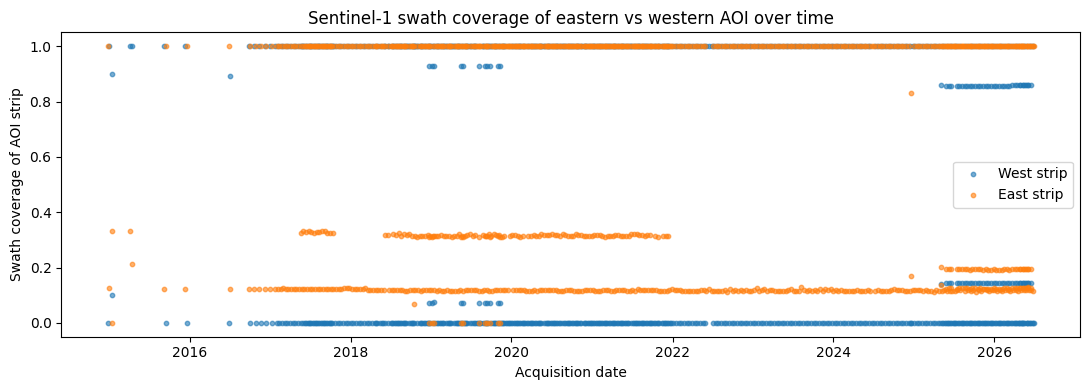

In [3]:
# === DIAGNOSTIC: Sentinel-1 eastern-AOI swath coverage over time ===
# Self-contained: only needs `ee` (initialised above), the `winam` AOI, and the
# S1_START_DATE / EXPORT_END_DATE settings. Safe to run before the predictor
# functions are defined.
import pandas as pd

# Eastern vs western reference strips inside the AOI (longitude bands).
# AOI is ee.Geometry.Rectangle([34, -0.55, 34.9, 0]); the gulf's water tip and
# the eastern edge sit east of ~34.7, which is where the swath edge cuts in.
S1_DIAG_EAST_STRIP = ee.Geometry.Rectangle([34.70, -0.55, 34.90, 0.0], geodesic=False)
S1_DIAG_WEST_STRIP = ee.Geometry.Rectangle([34.00, -0.55, 34.20, 0.0], geodesic=False)
_s1_diag_east_area = S1_DIAG_EAST_STRIP.area(1)
_s1_diag_west_area = S1_DIAG_WEST_STRIP.area(1)

s1_diag_col = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(winam)
    .filterDate(S1_START_DATE, EXPORT_END_DATE)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
)


def _s1_diag_feature(img):
    geom = img.geometry()
    east_cov = geom.intersection(S1_DIAG_EAST_STRIP, 1).area(1).divide(_s1_diag_east_area)
    west_cov = geom.intersection(S1_DIAG_WEST_STRIP, 1).area(1).divide(_s1_diag_west_area)
    return ee.Feature(None, {
        'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
        'platform': img.get('platform_number'),
        'relorb': img.get('relativeOrbitNumber_start'),
        'orbitpass': img.get('orbitProperties_pass'),
        'east_cov': east_cov,
        'west_cov': west_cov,
    })


print('Querying Sentinel-1 footprints over the AOI; this can take a moment...')
s1_diag_info = s1_diag_col.map(_s1_diag_feature).getInfo()
s1_diag = pd.DataFrame([f['properties'] for f in s1_diag_info['features']])

if s1_diag.empty:
    print('No Sentinel-1 IW VV+VH scenes found over the AOI for the configured dates.')
else:
    s1_diag['date'] = pd.to_datetime(s1_diag['date'])
    s1_diag['year'] = s1_diag['date'].dt.year
    s1_diag['platform'] = 'S1' + s1_diag['platform'].astype(str)
    s1_diag['relorb'] = pd.to_numeric(s1_diag['relorb'], errors='coerce').astype('Int64')
    for _col in ['east_cov', 'west_cov']:
        s1_diag[_col] = pd.to_numeric(s1_diag[_col], errors='coerce').clip(0, 1)
    s1_diag = s1_diag.sort_values('date').reset_index(drop=True)

    print(
        f'Total S1 acquisition footprints: {len(s1_diag)} '
        f'({s1_diag["date"].dt.date.min()} to {s1_diag["date"].dt.date.max()})\n'
    )

    print('Scenes per year by platform (watch for S1B dropping out ~end 2021):')
    display(s1_diag.pivot_table(index='year', columns='platform', values='date',
                                aggfunc='count', fill_value=0))

    print('\nScenes per year by relative orbit (watch for a track that disappears):')
    display(s1_diag.pivot_table(index='year', columns='relorb', values='date',
                                aggfunc='count', fill_value=0))

    print('\nMean swath coverage of the EAST vs WEST AOI strip, per year:')
    cov_by_year = s1_diag.groupby('year')[['west_cov', 'east_cov']].mean().round(3)
    cov_by_year['scenes'] = s1_diag.groupby('year').size()
    display(cov_by_year)

    # Flag the pivot: first year the east strip is mostly uncovered while the west is fine.
    pivot = cov_by_year[(cov_by_year['east_cov'] < 0.5) & (cov_by_year['west_cov'] > 0.8)]
    if len(pivot):
        print(
            f'\n>>> Eastern AOI coverage collapses from {int(pivot.index[0])} onward '
            f'(east mean cov {pivot.iloc[0]["east_cov"]:.0%}, '
            f'west {pivot.iloc[0]["west_cov"]:.0%}).'
        )
    else:
        print('\nNo clear east-vs-west coverage split detected with the current strips/threshold.')

    print('\nEastern-strip coverage by relative orbit (which track reaches the east):')
    display(s1_diag.groupby('relorb')[['east_cov', 'west_cov']].mean().round(3))

    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.scatter(s1_diag['date'], s1_diag['west_cov'], s=10, label='West strip', alpha=0.6)
        ax.scatter(s1_diag['date'], s1_diag['east_cov'], s=10, label='East strip', alpha=0.6)
        ax.set_ylabel('Swath coverage of AOI strip')
        ax.set_xlabel('Acquisition date')
        ax.set_title('Sentinel-1 swath coverage of eastern vs western AOI over time')
        ax.set_ylim(-0.05, 1.05)
        ax.legend()
        fig.tight_layout()
        plt.show()
    except Exception as exc:
        print(f'(Skipped coverage plot: {type(exc).__name__}: {exc})')

## 3. Predictor band definitions

In [4]:
S2_BASE_PREDICTORS = [
    'AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI',
    'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2'
]

S2_WH_LEV_EXTRA_PREDICTORS = [
    "dist_to_shore_m",
    "nir_glcm_homogeneity_w5",
    "nir_glcm_entropy_w5",
    "nir_glcm_contrast_w5",
]

S2_PREDICTORS = S2_BASE_PREDICTORS + S2_WH_LEV_EXTRA_PREDICTORS
S2_EXPORT_SCHEMA_VERSION = "s2_whlev_texture_v1"
# Do not mix old S2 exports without these bands with new S2 exports using this schema.

S1_REF_ANGLE_DEGREES = 38.0
S1_PREDICTORS = ['VH_p5', 'VH_corrected', 'VH_smooth']

# Baseline periods copied from the existing Route B workflow.
S2_AWEI_P95_START = '2017-04-01'
S2_AWEI_P95_END = '2021-06-01'
S1_VH_P5_START = '2015-11-18'
S1_VH_P5_END = '2021-06-01'

print('S2 export band order:', S2_PREDICTORS)
print('S1 export band order:', S1_PREDICTORS)


S2 export band order: ['AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI', 'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2', 'dist_to_shore_m', 'nir_glcm_homogeneity_w5', 'nir_glcm_entropy_w5', 'nir_glcm_contrast_w5']
S1 export band order: ['VH_p5', 'VH_corrected', 'VH_smooth']


## 4. Water mask

In [5]:
def get_jrc_water_mask(aoi, occurrence_threshold=JRC_OCCURRENCE_THRESHOLD):
    return (
        ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
        .select('occurrence')
        .gte(occurrence_threshold)
        .rename('water_mask')
        .clip(aoi)
    )


def build_dist_to_shore_m_source(aoi, region=None, neighborhood=DIST_TO_SHORE_NEIGHBORHOOD_PX):
    """Heavy, date-independent distance-to-shore field.

    Baked once into DIST_TO_SHORE_TILE_COLLECTION_ID (section 4b); it is never
    evaluated inside a per-date export graph. fastDistanceTransform is a
    non-streamable neighbourhood operation, so we pin it to the coarse, metric
    DIST_TO_SHORE_SCALE grid with setDefaultProjection: that keeps pixel
    distances in metres.

    ``region`` is the export footprint of one bake tile (defaults to the whole
    ``aoi``). ``non_water`` is always derived from the full ``aoi`` so a tile's
    values are identical to a single full-AOI bake -- only the final clip
    restricts the output, which keeps the mosaic seamless.

    fastDistanceTransform reprojects a window of roughly
    ``region + 2 * neighborhood`` pixels. The old 4096 px neighborhood made that
    window 8448x8448 and the bake failed with 'Reprojection output too large';
    ``neighborhood`` now covers the AOI (~1024 px) and ``region`` is one tile,
    so the window stays small. The JRC Global Surface Water source is only ~30 m
    native, so no shoreline detail is lost on this grid.
    """
    water = get_jrc_water_mask(aoi, JRC_OCCURRENCE_THRESHOLD)

    # Source pixels for distance are non-water pixels.
    # Unmask outside known water as non-water so the edge behaves as shoreline.
    non_water = water.Not().unmask(1)

    dist_px = (
        non_water
        .setDefaultProjection(crs=EXPORT_CRS, scale=DIST_TO_SHORE_SCALE)
        .fastDistanceTransform(neighborhood)
        .sqrt()
    )

    return (
        dist_px
        .multiply(DIST_TO_SHORE_SCALE)
        .rename("dist_to_shore_m")
        .toFloat()
        .clip(region if region is not None else aoi)
    )


def dist_to_shore_tile_id(col, row):
    """Asset id of one bake tile inside the dist_to_shore tile collection."""
    return f'{DIST_TO_SHORE_TILE_COLLECTION_ID}/tile_r{row}_c{col}'


def dist_to_shore_tile_specs():
    """Lay out the bake tiles as a regular grid over the AOI bounding box.

    Each tile's export region is padded by DIST_TO_SHORE_TILE_PAD_DEG so
    neighbouring tiles overlap slightly and the mosaic has no gaps.
    """
    cols, rows = DIST_TO_SHORE_TILE_GRID
    west, south, east, north = WINAM_BBOX
    step_x = (east - west) / cols
    step_y = (north - south) / rows
    pad = DIST_TO_SHORE_TILE_PAD_DEG

    specs = []
    for row in range(rows):
        for col in range(cols):
            tile_west = west + col * step_x - pad
            tile_east = west + (col + 1) * step_x + pad
            tile_south = south + row * step_y - pad
            tile_north = south + (row + 1) * step_y + pad
            region = ee.Geometry.Rectangle(
                [tile_west, tile_south, tile_east, tile_north],
                proj='EPSG:4326',
                geodesic=False,
            )
            specs.append({
                'col': col,
                'row': row,
                'asset_id': dist_to_shore_tile_id(col, row),
                'region': region,
            })
    return specs


def _ee_asset_exists(asset_id):
    try:
        ee.data.getAsset(asset_id)
        return True
    except Exception:
        return False


def dist_to_shore_collection_exists():
    return _ee_asset_exists(DIST_TO_SHORE_TILE_COLLECTION_ID)


def dist_to_shore_tiles_ready():
    """True only when the tile collection exists with every expected tile baked."""
    if not dist_to_shore_collection_exists():
        return False
    return all(_ee_asset_exists(spec['asset_id']) for spec in dist_to_shore_tile_specs())


def load_dist_to_shore_m():
    """Load the pre-baked static dist_to_shore_m raster.

    The field is baked as a grid of per-tile assets (section 4b); mosaicking
    that collection stitches them back into one seamless image. Each tile is a
    plain raster on a fixed DIST_TO_SHORE_SCALE projection, so resampling the
    mosaic to the 10 m export grid is streamed tile-by-tile. No
    fastDistanceTransform / reproject node ever enters a per-date export graph,
    which is what made every export fail with 'Reprojection output too large'.
    """
    return (
        ee.ImageCollection(DIST_TO_SHORE_TILE_COLLECTION_ID)
        .mosaic()
        .resample("bilinear")
        .rename("dist_to_shore_m")
        .toFloat()
    )


def apply_optional_water_mask_to_predictor_image(predictor_img, aoi):
    if APPLY_JRC_WATER_MASK:
        return predictor_img.updateMask(get_jrc_water_mask(aoi, JRC_OCCURRENCE_THRESHOLD))
    return predictor_img


def get_coverage_denominator_mask(aoi):
    if VALID_COVERAGE_DENOMINATOR.lower() == 'water':
        return get_jrc_water_mask(aoi, JRC_OCCURRENCE_THRESHOLD).selfMask().rename('denominator')
    if VALID_COVERAGE_DENOMINATOR.lower() == 'aoi':
        return ee.Image.constant(1).clip(aoi).selfMask().rename('denominator')
    raise ValueError("VALID_COVERAGE_DENOMINATOR must be 'water' or 'aoi'.")


print('JRC water mask applied before export:', APPLY_JRC_WATER_MASK)


JRC water mask applied before export: True


## 4b. Bake the static dist_to_shore_m field (run once, tiled)

`dist_to_shore_m` does not depend on the acquisition date, but `fastDistanceTransform` is a non-streamable neighbourhood operation. `fastDistanceTransform(neighborhood)` reprojects a window of roughly `export_region + 2 * neighborhood` pixels on **every** task, so the old single-image bake with a 4096 px neighborhood tried to reproject an 8448×8448 window and failed with `Reprojection output too large (8448x8448 pixels)`. Tiling the export region alone does not fix that, because the window is dominated by `2 * neighborhood`, not by the region.

This cell instead bakes the field as a small grid of per-tile image assets inside one `ImageCollection`: the neighborhood is sized to the AOI (~1024 px, well above the largest true distance-to-shore) and each tile exports only a sub-region, so every task's reprojection window stays small. `load_dist_to_shore_m()` mosaics the tiles back into one seamless raster, so every per-date export still loads a plain raster with no `fastDistanceTransform` node in its graph. The bakes run asynchronously (a few minutes each) — if this cell reports tiles are still building, wait for the tasks to finish and re-run it before exporting.

In [ ]:
DIST_TO_SHORE_BAKE_DESCRIPTION = 'winam_dist_to_shore_m_bake'


def _dist_to_shore_tile_description(col, row):
    """Earth Engine task description for one bake tile."""
    return f'{DIST_TO_SHORE_BAKE_DESCRIPTION}_r{row}_c{col}'


def _active_dist_to_shore_bake_tasks():
    """Map task description -> state for in-flight dist_to_shore bake tasks."""
    active = {}
    for task in ee.batch.Task.list():
        try:
            status = task.status()
        except Exception:
            continue
        description = str(status.get('description', ''))
        state = str(status.get('state', '')).upper()
        if (description.startswith(DIST_TO_SHORE_BAKE_DESCRIPTION)
                and state in EE_ACTIVE_TASK_STATES):
            active[description] = state
    return active


def ensure_dist_to_shore_tile_collection():
    """Create the ImageCollection that holds the bake tiles, if missing."""
    if dist_to_shore_collection_exists():
        return
    ee.data.createAsset({'type': 'ImageCollection'}, DIST_TO_SHORE_TILE_COLLECTION_ID)
    print(f'Created dist_to_shore tile collection: {DIST_TO_SHORE_TILE_COLLECTION_ID}')


def delete_dist_to_shore_tiles():
    """Delete every tile in the collection and the collection container."""
    if not dist_to_shore_collection_exists():
        return
    try:
        children = ee.data.getList({'id': DIST_TO_SHORE_TILE_COLLECTION_ID})
    except Exception:
        children = []
    for child in children:
        ee.data.deleteAsset(child['id'])
    ee.data.deleteAsset(DIST_TO_SHORE_TILE_COLLECTION_ID)


def start_dist_to_shore_tile_export(spec):
    task = ee.batch.Export.image.toAsset(
        image=build_dist_to_shore_m_source(winam, region=spec['region']),
        description=_dist_to_shore_tile_description(spec['col'], spec['row']),
        assetId=spec['asset_id'],
        region=spec['region'],
        scale=DIST_TO_SHORE_SCALE,
        crs=EXPORT_CRS,
        maxPixels=1e13,
    )
    task.start()
    return task


def ensure_dist_to_shore_asset(rebuild=REBUILD_DIST_TO_SHORE_ASSET):
    """Ensure the dist_to_shore tile collection exists and is fully baked.

    Returns True when every tile is ready to use, False when one or more tiles
    are still baking (re-run this cell once the bake tasks complete). The field
    is tiled and mosaicked at load time so a heavy fastDistanceTransform never
    enters a per-date export graph.
    """
    if rebuild and dist_to_shore_collection_exists():
        print(f'Deleting existing dist_to_shore tiles for rebuild: {DIST_TO_SHORE_TILE_COLLECTION_ID}')
        delete_dist_to_shore_tiles()

    if dist_to_shore_tiles_ready():
        print(f'dist_to_shore tiles ready: {DIST_TO_SHORE_TILE_COLLECTION_ID}')
        return True

    active = _active_dist_to_shore_bake_tasks()
    ensure_dist_to_shore_tile_collection()

    started = 0
    still_baking = 0
    for spec in dist_to_shore_tile_specs():
        if _ee_asset_exists(spec['asset_id']):
            continue
        description = _dist_to_shore_tile_description(spec['col'], spec['row'])
        if description in active:
            still_baking += 1
            print(f'  tile r{spec["row"]} c{spec["col"]} still baking (task state: {active[description]}).')
            continue
        task = start_dist_to_shore_tile_export(spec)
        started += 1
        print(f'  started tile r{spec["row"]} c{spec["col"]} bake: {description} (task id {task.id}).')

    print(
        f'dist_to_shore bake: {started} tile task(s) started this run, '
        f'{still_baking} already running. Each runs once (a few minutes).'
    )
    print('Re-run this cell when the tasks complete; exports are gated on the tiles being ready.')
    return False


DIST_TO_SHORE_READY = ensure_dist_to_shore_asset()
print('dist_to_shore tiles ready:', DIST_TO_SHORE_READY)

## 5. Sentinel-2 predictor functions

In [6]:
def mask_s2_sr(img):
    scl = img.select('SCL')
    mask = (
        scl.neq(3)    # cloud shadow
        .And(scl.neq(8))    # medium probability cloud
        .And(scl.neq(9))    # high probability cloud
        .And(scl.neq(10))   # thin cirrus
        .And(scl.neq(11))   # snow/ice
    )
    return img.updateMask(mask)


def add_s2_predictors(img):
    bands = img.select(
        ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12'],
        ['B',  'G',  'R',  'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2']
    ).toFloat()

    ndvi = bands.normalizedDifference(['NIR', 'R']).rename('NDVI')
    ndmi = bands.normalizedDifference(['NIR', 'SWIR']).rename('NDMI')
    mndwi = bands.normalizedDifference(['G', 'SWIR']).rename('MNDWI')

    awei = bands.expression(
        'B + 2.5 * G - 1.5 * (NIR + SWIR) - 0.25 * SWIR2',
        {
            'B': bands.select('B'),
            'G': bands.select('G'),
            'NIR': bands.select('NIR'),
            'SWIR': bands.select('SWIR'),
            'SWIR2': bands.select('SWIR2')
        }
    ).rename('AWEI')

    aweinsh = bands.expression(
        '4 * (G - SWIR) - (0.25 * NIR + 2.75 * SWIR2)',
        {
            'G': bands.select('G'),
            'NIR': bands.select('NIR'),
            'SWIR': bands.select('SWIR'),
            'SWIR2': bands.select('SWIR2')
        }
    ).rename('AWEInsh')

    return bands.addBands([ndvi, ndmi, mndwi, awei, aweinsh])


def add_nir_glcm_texture_w5(s2_predictor_img):
    nir = s2_predictor_img.select("NIR")

    # S2 surface reflectance bands are kept in their native 0-10000 scale.
    nir_u8 = (
        nir
        .unitScale(0, 10000)
        .multiply(255)
        .clamp(0, 255)
        .toUint8()
        .rename("nir_u8")
    )

    glcm = nir_u8.glcmTexture(size=5)

    texture = ee.Image.cat([
        glcm.select("nir_u8_idm").rename("nir_glcm_homogeneity_w5"),
        glcm.select("nir_u8_ent").rename("nir_glcm_entropy_w5"),
        glcm.select("nir_u8_contrast").rename("nir_glcm_contrast_w5"),
    ]).toFloat()

    return s2_predictor_img.addBands(texture)


def get_s2_source_collection(start_date, end_date, aoi, cloud_pct=S2_CLOUD_PCT):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_pct))
    )


def get_s2_collection(start_date, end_date, aoi, cloud_pct=S2_CLOUD_PCT):
    return (
        get_s2_source_collection(start_date, end_date, aoi, cloud_pct)
        .map(mask_s2_sr)
        .map(add_s2_predictors)
    )


def get_s2_awei_p95(aoi):
    return (
        get_s2_collection(S2_AWEI_P95_START, S2_AWEI_P95_END, aoi)
        .select('AWEI')
        .reduce(ee.Reducer.percentile([95]))
        .rename('AWEI_p95')
        .toFloat()
    )


S2_AWEI_P95_IMAGE = get_s2_awei_p95(winam)


def get_s2_predictor_image(start_date, end_date, aoi):
    # This is a one-day/acquisition-date snapshot, not a monthly composite.
    # Median is only used to combine overlapping same-date granules/tiles.
    collection = get_s2_collection(start_date, end_date, aoi)
    dist_to_shore = load_dist_to_shore_m()
    image = (
        collection
        .median()
        .addBands(S2_AWEI_P95_IMAGE)
        .addBands(dist_to_shore)
    )
    image = add_nir_glcm_texture_w5(image)
    image = (
        image
        .select(S2_PREDICTORS)
        .clip(aoi)
    )
    return apply_optional_water_mask_to_predictor_image(image, aoi)


print('S2 diagnostic includes dist_to_shore_m:', 'dist_to_shore_m' in S2_PREDICTORS)
print('S2 diagnostic includes NIR GLCM texture bands:', all(
    band in S2_PREDICTORS
    for band in [
        'nir_glcm_homogeneity_w5',
        'nir_glcm_entropy_w5',
        'nir_glcm_contrast_w5',
    ]
))


S2 diagnostic includes dist_to_shore_m: True
S2 diagnostic includes NIR GLCM texture bands: True


## 5a. Diagnostic: validate new S2 predictor schema

This diagnostic validates band presence and non-null values on a small AOI-centred chip. Keeping the diagnostic geometry bounded avoids forcing Earth Engine to reproject the full Winam AOI just to inspect the new distance/texture bands, which can raise `Reprojection output too large` during interactive `reduceRegion` calls.


In [7]:
if not DIST_TO_SHORE_READY:
    print('Skipping S2 schema validation: dist_to_shore asset is still baking.')
    print('Re-run section 4b once the asset bake completes, then re-run this cell.')
else:
    required_new_s2_bands = {
        "dist_to_shore_m",
        "nir_glcm_homogeneity_w5",
        "nir_glcm_entropy_w5",
        "nir_glcm_contrast_w5",
    }

    # Keep this interactive diagnostic small. The production export still uses the
    # full ``winam`` AOI below, but validating the schema over the full AOI can force
    # Earth Engine to materialise a large reprojection for fastDistanceTransform /
    # GLCM texture and fail with "Reprojection output too large".
    S2_SCHEMA_VALIDATION_BUFFER_M = 5000
    s2_validation_aoi = winam.centroid(maxError=EXPORT_SCALE).buffer(S2_SCHEMA_VALIDATION_BUFFER_M).bounds(maxError=EXPORT_SCALE)

    s2_validation_source = get_s2_source_collection(S2_START_DATE, EXPORT_END_DATE, winam, S2_CLOUD_PCT).sort('system:time_start')
    s2_validation_first = ee.Image(s2_validation_source.first())
    s2_validation_start = ee.Date(s2_validation_first.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    s2_validation_end = (pd.to_datetime(s2_validation_start) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

    s2_test = get_s2_predictor_image(s2_validation_start, s2_validation_end, s2_validation_aoi)
    actual_bands = set(s2_test.bandNames().getInfo())
    missing = required_new_s2_bands - actual_bands
    assert not missing, f"Missing new S2 predictor bands: {missing}"

    new_s2_band_counts = s2_test.select(sorted(required_new_s2_bands)).reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=s2_validation_aoi,
        scale=EXPORT_SCALE,
        crs=EXPORT_CRS,
        maxPixels=1e8,
        tileScale=VALID_STATS_TILE_SCALE,
    ).getInfo()
    empty_new_s2_bands = {band: count for band, count in new_s2_band_counts.items() if not count}
    assert not empty_new_s2_bands, f"New S2 predictor bands are fully masked/null in the validation chip: {empty_new_s2_bands}"

    print('S2 validation date:', s2_validation_start)
    print('S2 schema validation buffer (m):', S2_SCHEMA_VALIDATION_BUFFER_M)
    print(s2_test.bandNames().getInfo())
    print('New S2 band non-null pixel counts in validation chip:', new_s2_band_counts)



S2 validation date: 2017-04-02
S2 schema validation buffer (m): 5000
['AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI', 'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2', 'dist_to_shore_m', 'nir_glcm_homogeneity_w5', 'nir_glcm_entropy_w5', 'nir_glcm_contrast_w5']
New S2 band non-null pixel counts in validation chip: {'dist_to_shore_m': 766703, 'nir_glcm_contrast_w5': 766703, 'nir_glcm_entropy_w5': 766703, 'nir_glcm_homogeneity_w5': 766703}


## 6. Sentinel-1 SCC predictor functions

In [8]:
def add_s1_predictors_exact_scc(img, ref_angle_degrees=S1_REF_ANGLE_DEGREES):
    theta = img.select('angle').multiply(math.pi / 180.0)
    theta_ref = ee.Image.constant(ref_angle_degrees * math.pi / 180.0)

    correction_db = theta_ref.cos().pow(2).divide(theta.cos().pow(2)).log10().multiply(10.0)

    vh_corrected = img.select('VH').add(correction_db).rename('VH_corrected').toFloat()
    vv_corrected = img.select('VV').add(correction_db).rename('VV_corrected').toFloat()

    kernel_5x5 = ee.Kernel.square(radius=2, units='pixels', normalize=False)
    vh_smooth = vh_corrected.focal_median(kernel=kernel_5x5).rename('VH_smooth').toFloat()
    vv_smooth = vv_corrected.focal_median(kernel=kernel_5x5).rename('VV_smooth').toFloat()

    return img.addBands([vh_corrected, vv_corrected, vh_smooth, vv_smooth], overwrite=True)


def get_s1_source_collection(start_date, end_date, aoi):
    return (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    )


def get_s1_collection(start_date, end_date, aoi):
    return get_s1_source_collection(start_date, end_date, aoi).map(add_s1_predictors_exact_scc)


def get_s1_vh_p5(aoi):
    return (
        get_s1_collection(S1_VH_P5_START, S1_VH_P5_END, aoi)
        .select('VH_corrected')
        .reduce(ee.Reducer.percentile([5]))
        .rename('VH_p5')
        .toFloat()
    )


S1_VH_P5_IMAGE = get_s1_vh_p5(winam)


def get_s1_predictor_image(start_date, end_date, aoi):
    collection = get_s1_collection(start_date, end_date, aoi)
    image = (
        collection
        .median()
        .addBands(S1_VH_P5_IMAGE)
        .select(S1_PREDICTORS)
        .clip(aoi)
    )
    return apply_optional_water_mask_to_predictor_image(image, aoi)


## 7. Build the acquisition-date manifest

In [9]:
def _add_date_property(img):
    return img.set('date_string', ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'))


def date_count_table(collection):
    hist = collection.map(_add_date_property).aggregate_histogram('date_string').getInfo()
    if not hist:
        return pd.DataFrame(columns=['date', 'image_count'])
    out = (
        pd.DataFrame({'date': list(hist.keys()), 'image_count': list(hist.values())})
        .sort_values('date')
        .reset_index(drop=True)
    )
    out['image_count'] = out['image_count'].astype(int)
    return out


def add_one_day_period_columns(df):
    df = df.copy()
    df['start_date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
    df['end_date'] = (pd.to_datetime(df['date']) + pd.Timedelta(days=1)).dt.strftime('%Y-%m-%d')
    return df


def build_export_manifest():
    manifest_parts = []

    if EXPORT_S2:
        s2_source = get_s2_source_collection(S2_START_DATE, EXPORT_END_DATE, winam, S2_CLOUD_PCT)
        s2_dates = add_one_day_period_columns(date_count_table(s2_source))
        s2_dates['sensor'] = 'S2'
        s2_dates['prefix'] = s2_dates.apply(
            lambda r: f"winam_s2_predictors_{S2_EXPORT_SCHEMA_VERSION}_{r['start_date']}_to_{r['end_date']}",
            axis=1
        )
        s2_dates['band_order'] = ','.join(S2_PREDICTORS)
        manifest_parts.append(s2_dates)
        print('S2 planned acquisition-date snapshot exports before coverage QA:', len(s2_dates))

    if EXPORT_S1:
        s1_source = get_s1_source_collection(S1_START_DATE, EXPORT_END_DATE, winam)
        s1_dates = add_one_day_period_columns(date_count_table(s1_source))
        s1_dates['sensor'] = 'S1'
        s1_dates['prefix'] = s1_dates.apply(
            lambda r: f"winam_s1_scc_predictors_{r['start_date']}_to_{r['end_date']}",
            axis=1
        )
        s1_dates['band_order'] = ','.join(S1_PREDICTORS)
        manifest_parts.append(s1_dates)
        print('S1 planned acquisition-date snapshot exports before coverage QA:', len(s1_dates))

    if not manifest_parts:
        return pd.DataFrame(columns=['manifest_row', 'sensor', 'date', 'start_date', 'end_date', 'image_count', 'prefix', 'band_order'])

    manifest = pd.concat(manifest_parts, ignore_index=True)
    manifest = manifest[['sensor', 'date', 'start_date', 'end_date', 'image_count', 'prefix', 'band_order']]
    manifest = manifest.sort_values(['start_date', 'sensor']).reset_index(drop=True)
    manifest.insert(0, 'manifest_row', range(len(manifest)))
    return manifest


planned_manifest = build_export_manifest()
planned_manifest.to_csv(PLANNED_MANIFEST_PATH, index=False)
manifest = planned_manifest

print('Total planned single-date snapshot rows before coverage QA:', len(planned_manifest))
print('Saved planned rows:', PLANNED_MANIFEST_PATH)
display(planned_manifest.head(10))
display(planned_manifest.tail(10))


S2 planned acquisition-date snapshot exports before coverage QA: 568
S1 planned acquisition-date snapshot exports before coverage QA: 894
Total planned single-date snapshot rows before coverage QA: 1462
Saved planned rows: /content/drive/MyDrive/GEE_Exports_validated_snapshots/winam_snapshot_validated_predictor_planned_rows.csv


,manifest_row,sensor,date,start_date,end_date,image_count,prefix,band_order
0,0,S1,2014-12-25,2014-12-25,2014-12-26,1,winam_s1_scc_predictors_2014-12-25_to_2014-12-26,"VH_p5,VH_corrected,VH_smooth"
1,1,S1,2014-12-30,2014-12-30,2014-12-31,1,winam_s1_scc_predictors_2014-12-30_to_2014-12-31,"VH_p5,VH_corrected,VH_smooth"
2,2,S1,2015-01-13,2015-01-13,2015-01-14,2,winam_s1_scc_predictors_2015-01-13_to_2015-01-14,"VH_p5,VH_corrected,VH_smooth"
3,3,S1,2015-04-07,2015-04-07,2015-04-08,1,winam_s1_scc_predictors_2015-04-07_to_2015-04-08,"VH_p5,VH_corrected,VH_smooth"
4,4,S1,2015-04-17,2015-04-17,2015-04-18,1,winam_s1_scc_predictors_2015-04-17_to_2015-04-18,"VH_p5,VH_corrected,VH_smooth"
5,5,S1,2015-09-08,2015-09-08,2015-09-09,1,winam_s1_scc_predictors_2015-09-08_to_2015-09-09,"VH_p5,VH_corrected,VH_smooth"
6,6,S1,2015-09-15,2015-09-15,2015-09-16,1,winam_s1_scc_predictors_2015-09-15_to_2015-09-16,"VH_p5,VH_corrected,VH_smooth"
7,7,S1,2015-12-13,2015-12-13,2015-12-14,1,winam_s1_scc_predictors_2015-12-13_to_2015-12-14,"VH_p5,VH_corrected,VH_smooth"
8,8,S1,2015-12-20,2015-12-20,2015-12-21,1,winam_s1_scc_predictors_2015-12-20_to_2015-12-21,"VH_p5,VH_corrected,VH_smooth"
9,9,S1,2016-06-29,2016-06-29,2016-06-30,1,winam_s1_scc_predictors_2016-06-29_to_2016-06-30,"VH_p5,VH_corrected,VH_smooth"


,manifest_row,sensor,date,start_date,end_date,image_count,prefix,band_order
1452,1452,S1,2026-06-15,2026-06-15,2026-06-16,2,winam_s1_scc_predictors_2026-06-15_to_2026-06-16,"VH_p5,VH_corrected,VH_smooth"
1453,1453,S2,2026-06-16,2026-06-16,2026-06-17,4,winam_s2_predictors_s2_whlev_texture_v1_2026-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE..."
1454,1454,S1,2026-06-18,2026-06-18,2026-06-19,1,winam_s1_scc_predictors_2026-06-18_to_2026-06-19,"VH_p5,VH_corrected,VH_smooth"
1455,1455,S2,2026-06-19,2026-06-19,2026-06-20,4,winam_s2_predictors_s2_whlev_texture_v1_2026-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE..."
1456,1456,S1,2026-06-22,2026-06-22,2026-06-23,1,winam_s1_scc_predictors_2026-06-22_to_2026-06-23,"VH_p5,VH_corrected,VH_smooth"
1457,1457,S2,2026-06-24,2026-06-24,2026-06-25,4,winam_s2_predictors_s2_whlev_texture_v1_2026-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE..."
1458,1458,S1,2026-06-25,2026-06-25,2026-06-26,2,winam_s1_scc_predictors_2026-06-25_to_2026-06-26,"VH_p5,VH_corrected,VH_smooth"
1459,1459,S2,2026-06-26,2026-06-26,2026-06-27,4,winam_s2_predictors_s2_whlev_texture_v1_2026-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE..."
1460,1460,S1,2026-06-28,2026-06-28,2026-06-29,1,winam_s1_scc_predictors_2026-06-28_to_2026-06-29,"VH_p5,VH_corrected,VH_smooth"
1461,1461,S2,2026-06-29,2026-06-29,2026-06-30,4,winam_s2_predictors_s2_whlev_texture_v1_2026-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE..."


## 8. Run manifest and pending export selection


In [10]:
def utc_now_iso():
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def empty_run_manifest():
    return pd.DataFrame(columns=MANIFEST_COLUMNS)


def load_run_manifest(path=RUN_MANIFEST_PATH):
    path = Path(path)
    if RESET_EXPORT_MANIFEST and path.exists():
        path.unlink()
        print('Deleted run manifest:', path)

    if not path.exists():
        return empty_run_manifest()

    df = pd.read_csv(path)
    for column in MANIFEST_COLUMNS:
        if column not in df.columns:
            df[column] = None
    return df[MANIFEST_COLUMNS]


def save_run_manifest(df, path=RUN_MANIFEST_PATH):
    path = Path(path)
    df = df.copy()
    for column in MANIFEST_COLUMNS:
        if column not in df.columns:
            df[column] = None
    df[MANIFEST_COLUMNS].to_csv(path, index=False)
    return df[MANIFEST_COLUMNS]


def export_prefix_exists(prefix, export_dir=GEE_EXPORT_DIR):
    export_dir = Path(export_dir)
    patterns = [
        f'{prefix}',
        f'{prefix}.tif', f'{prefix}.TIF',
        f'{prefix}.tiff', f'{prefix}.TIFF',
        f'{prefix}-*', f'{prefix}-*.tif', f'{prefix}-*.TIF',
        f'{prefix}-*.tiff', f'{prefix}-*.TIFF',
    ]
    for pattern in patterns:
        if any(p.is_file() for p in export_dir.glob(pattern)):
            return True
    return False


def is_ee_operation_not_found(exc):
    message = str(exc)
    return 'Operation "projects/' in message and '" not found' in message


def task_config_value(task, key, default=None):
    config = getattr(task, 'config', None)
    if isinstance(config, dict) and key in config:
        return config.get(key)
    return default


def fallback_task_status(task, exc):
    task_id = getattr(task, 'id', None) or getattr(task, '_id', None)
    return {
        'id': task_id,
        'state': 'UNKNOWN',
        'description': task_config_value(task, 'description'),
        'error_message': f'operation_not_found_while_polling: {type(exc).__name__}: {exc}',
    }


def safe_task_status(task, context='', retries=3, initial_delay_seconds=2):
    '''
    Return task.status(), retrying/soft-failing Earth Engine's intermittent
    "Operation ... not found" polling error instead of crashing the notebook.

    Earth Engine exports can still be queued or already completed when this
    metadata endpoint temporarily cannot find the operation, so callers should
    use Drive files plus the run manifest as the source of truth for resuming.
    '''
    for attempt in range(retries + 1):
        try:
            return task.status()
        except Exception as exc:
            if not is_ee_operation_not_found(exc):
                raise
            if attempt < retries:
                delay = initial_delay_seconds * (2 ** attempt)
                label = f' ({context})' if context else ''
                print(
                    f'Warning: Earth Engine task status lookup returned Operation not found{label}; '
                    f'retrying in {delay}s ({attempt + 1}/{retries}).'
                )
                time.sleep(delay)
                continue
            label = f' ({context})' if context else ''
            print(
                f'Warning: Earth Engine task status lookup still returned Operation not found{label}; '
                'recording UNKNOWN status and continuing.'
            )
            return fallback_task_status(task, exc)


def make_manifest_record(row, status, stats=None, task=None, message=''):
    status_dict = safe_task_status(task, context=f"manifest record {row['prefix']}") if task is not None else {}
    task_id = (status_dict.get('id') or getattr(task, 'id', None)) if task is not None else None
    return {
        'sensor': row['sensor'],
        'start_date': row['start_date'],
        'end_date': row['end_date'],
        'prefix': row['prefix'],
        'valid_pixels': None if stats is None else int(round(float(stats['valid_pixels']))),
        'denominator_pixels': None if stats is None else int(round(float(stats['denominator_pixels']))),
        'valid_fraction': None if stats is None else float(stats['valid_fraction']),
        'status': status,
        'task_id': task_id,
        'message': message,
        'recorded_at': utc_now_iso(),
    }


def upsert_run_manifest_record(record, run_manifest=None, path=RUN_MANIFEST_PATH):
    if run_manifest is None:
        run_manifest = load_run_manifest(path)
    run_manifest = run_manifest.copy()
    same_prefix = run_manifest['prefix'].astype(str).eq(str(record['prefix']))
    if same_prefix.any():
        for column in MANIFEST_COLUMNS:
            run_manifest.loc[same_prefix, column] = record.get(column)
    else:
        run_manifest = pd.concat([run_manifest, pd.DataFrame([record])], ignore_index=True)
    return save_run_manifest(run_manifest, path)


def earth_engine_task_table():
    rows = []
    for task in ee.batch.Task.list():
        status = safe_task_status(task, context='task table')
        rows.append({
            'task_id': status.get('id'),
            'state': status.get('state'),
            'description': status.get('description'),
            'error_message': status.get('error_message'),
        })
    return pd.DataFrame(rows, columns=['task_id', 'state', 'description', 'error_message'])


def active_earth_engine_export_tasks(task_table=None):
    if task_table is None:
        task_table = earth_engine_task_table()
    if task_table.empty:
        return task_table.copy()
    active_states = {str(state).upper() for state in EE_ACTIVE_TASK_STATES}
    return task_table.loc[
        task_table['state'].astype(str).str.upper().isin(active_states)
        & task_table['description'].notna()
    ].copy()


def active_task_prefixes(task_table=None):
    active_tasks = active_earth_engine_export_tasks(task_table)
    if active_tasks.empty:
        return set()
    return set(active_tasks['description'].astype(str))


def most_recent_active_manifest_row(manifest_df, active_prefix_set):
    if not active_prefix_set:
        return None
    matches = manifest_df.loc[manifest_df['prefix'].astype(str).isin(active_prefix_set)]
    if matches.empty:
        return None
    return int(matches['manifest_row'].max())


# Rows with these statuses are not queued again. 'failed' is intentionally
# absent: once refresh_manifest_task_statuses flips a row whose Earth Engine
# task failed to that state, the next run re-queues it, so the batch self-heals
# after a fixed export bug without hand-editing the manifest. (Active rows stay
# queued/ready/running and completed/in-Drive rows are skipped separately, so
# only genuinely failed rows are retried.) Cancelled rows remain skipped to
# respect deliberate cancellations; delete such a row from RUN_MANIFEST_PATH or
# change its status manually to retry it.
RESUME_SKIP_STATUSES = {
    'queued', 'ready', 'running', 'completed', 'cancelled',
    'skipped_low_coverage', 'skipped_existing'
}

run_manifest = load_run_manifest(RUN_MANIFEST_PATH)
processed_prefixes = set(
    run_manifest.loc[
        run_manifest['status'].astype(str).str.lower().isin(RESUME_SKIP_STATUSES),
        'prefix'
    ].astype(str)
)

ee_task_table = earth_engine_task_table() if SKIP_PREFIXES_ALREADY_IN_EE_TASKS else pd.DataFrame()
ee_active_prefixes = active_task_prefixes(ee_task_table) if SKIP_PREFIXES_ALREADY_IN_EE_TASKS else set()
most_recent_active_row = most_recent_active_manifest_row(planned_manifest, ee_active_prefixes)

manifest_for_export = planned_manifest.copy()
manifest_for_export['already_recorded_in_manifest'] = manifest_for_export['prefix'].astype(str).isin(processed_prefixes)
manifest_for_export['already_active_ee_task'] = manifest_for_export['prefix'].astype(str).isin(ee_active_prefixes)
manifest_for_export['before_or_at_recent_active_task'] = False
if RESUME_AFTER_MOST_RECENT_ACTIVE_TASK and most_recent_active_row is not None:
    manifest_for_export['before_or_at_recent_active_task'] = (
        manifest_for_export['manifest_row'] <= most_recent_active_row
    )
manifest_for_export['already_in_drive'] = False

if SKIP_PREFIXES_ALREADY_IN_DRIVE:
    manifest_for_export['already_in_drive'] = manifest_for_export['prefix'].apply(export_prefix_exists)

# Record Drive exports that already exist so future runs can resume from the CSV alone.
existing_drive_rows = manifest_for_export.loc[
    manifest_for_export['already_in_drive']
    & ~manifest_for_export['already_recorded_in_manifest']
]
if len(existing_drive_rows):
    print(f'Recording {len(existing_drive_rows)} existing Drive exports in the run manifest.')
    for _, existing_row in existing_drive_rows.iterrows():
        record = make_manifest_record(
            existing_row,
            status='skipped_existing',
            message='prefix_already_exists_in_drive'
        )
        run_manifest = upsert_run_manifest_record(record, run_manifest)
    manifest_for_export.loc[existing_drive_rows.index, 'already_recorded_in_manifest'] = True

if MANUAL_START_AT_MANIFEST_ROW is not None:
    manifest_for_export = manifest_for_export.loc[
        manifest_for_export['manifest_row'] >= int(MANUAL_START_AT_MANIFEST_ROW)
    ].copy()

pending_manifest = (
    manifest_for_export
    .loc[
        ~manifest_for_export['already_recorded_in_manifest']
        & ~manifest_for_export['already_in_drive']
        & ~manifest_for_export['already_active_ee_task']
        & ~manifest_for_export['before_or_at_recent_active_task']
    ]
    .reset_index(drop=True)
)
pending_manifest.to_csv(PENDING_MANIFEST_PATH, index=False)

print('Run manifest rows:', len(run_manifest))
print('Total planned snapshot rows:', len(planned_manifest))
print('Already recorded in run manifest:', int(manifest_for_export['already_recorded_in_manifest'].sum()))
print('Already exported in Drive:', int(manifest_for_export['already_in_drive'].sum()))
print('Active matching Earth Engine tasks:', int(manifest_for_export['already_active_ee_task'].sum()))
if most_recent_active_row is None:
    print('Most recent active Earth Engine manifest row: none found')
else:
    print('Most recent active Earth Engine manifest row:', most_recent_active_row)
    print('Rows before/at most recent active task skipped by resume cursor:', int(manifest_for_export['before_or_at_recent_active_task'].sum()))
print('Pending rows to QA/queue:', len(pending_manifest))
print('Saved pending rows:', PENDING_MANIFEST_PATH)

if SKIP_PREFIXES_ALREADY_IN_EE_TASKS and len(ee_active_prefixes):
    active_preview = manifest_for_export.loc[manifest_for_export['already_active_ee_task']].copy()
    print('\nMatching active Earth Engine tasks already in READY/RUNNING state:')
    display(active_preview[['manifest_row', 'sensor', 'start_date', 'end_date', 'prefix']].tail(20))

if len(pending_manifest):
    print('\nNext rows to QA/queue:')
    display(pending_manifest.head(min(20, len(pending_manifest))))
else:
    print('\nNo pending rows to QA/queue under the current resume/skip settings.')


Run manifest rows: 1552
Total planned snapshot rows: 1462
Already recorded in run manifest: 889
Already exported in Drive: 456
Active matching Earth Engine tasks: 0
Most recent active Earth Engine manifest row: none found
Pending rows to QA/queue: 573
Saved pending rows: /content/drive/MyDrive/GEE_Exports_validated_snapshots/winam_snapshot_validated_predictor_pending_rows.csv

Next rows to QA/queue:


,manifest_row,sensor,date,start_date,end_date,image_count,prefix,band_order,already_recorded_in_manifest,already_active_ee_task,before_or_at_recent_active_task,already_in_drive
0,33,S2,2017-04-02,2017-04-02,2017-04-03,4,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
1,35,S2,2017-04-12,2017-04-12,2017-04-13,2,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
2,44,S2,2017-05-22,2017-05-22,2017-05-23,2,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
3,49,S2,2017-06-06,2017-06-06,2017-06-07,1,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
4,51,S2,2017-06-11,2017-06-11,2017-06-12,3,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
5,59,S2,2017-07-01,2017-07-01,2017-07-02,1,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
6,77,S2,2017-08-20,2017-08-20,2017-08-21,2,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
7,80,S2,2017-08-25,2017-08-25,2017-08-26,1,winam_s2_predictors_s2_whlev_texture_v1_2017-0...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
8,94,S2,2017-10-04,2017-10-04,2017-10-05,4,winam_s2_predictors_s2_whlev_texture_v1_2017-1...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False
9,108,S2,2017-12-13,2017-12-13,2017-12-14,2,winam_s2_predictors_s2_whlev_texture_v1_2017-1...,"AWEI_p95,AWEI,AWEInsh,NDMI,MNDWI,NDVI,B,G,R,RE...",False,False,False,False


## 9. Valid-pixel coverage QA helpers

In [ ]:
def get_valid_all_band_mask(image, band_order):
    '''
    Returns a binary image where every requested QA band has valid data.
    Important: call this before the final export unmask(-9999).
    '''
    if not band_order:
        raise ValueError('band_order must contain at least one band for coverage QA.')
    return (
        image
        .select(band_order)
        .mask()
        .reduce(ee.Reducer.min())
        .rename('valid_all_bands')
        .gt(0)
    )


def get_qa_band_order(sensor, band_order):
    '''
    Returns the predictor bands used for synchronous valid-coverage QA.

    Multi-year baseline bands are excluded from the QA mask because otherwise
    each per-date getInfo() request may force Earth Engine to recompute the
    full baseline percentile image. Reprojection-sensitive derived bands
    (dist_to_shore_m and the NIR GLCM texture bands) are excluded for a
    different reason: reducing their per-pixel validity over the full AOI forces
    Earth Engine to materialise a full-AOI reprojection and raises
    'Reprojection output too large'. All of these excluded bands are still
    written to the exported GeoTIFF.
    '''
    sensor = str(sensor).upper()
    excluded = set(QA_EXCLUDED_BASELINE_BANDS.get(sensor, []))
    excluded |= set(QA_EXCLUDED_REPROJECTION_BANDS.get(sensor, []))
    qa_bands = [band for band in band_order if band not in excluded]
    if not qa_bands:
        raise ValueError(f'No QA bands remain for sensor {sensor}; check QA_EXCLUDED_BASELINE_BANDS.')
    return qa_bands


def get_valid_pixel_stats(image, band_order, aoi, tile_scale=VALID_STATS_TILE_SCALE):
    '''
    Counts valid all-band pixels and valid coverage fraction over the selected
    denominator mask, usually the JRC Winam water mask.

    The numerator and denominator are reduced in a single Earth Engine request
    to keep notebook-side QA lightweight enough for repeated batch export runs.
    '''
    valid_all_bands = get_valid_all_band_mask(image, band_order)
    denominator = get_coverage_denominator_mask(aoi)

    # 1 inside denominator where all requested QA bands are valid, 0 elsewhere.
    valid_binary = (
        valid_all_bands
        .updateMask(denominator)
        .unmask(0)
        .rename('valid_pixels')
    )

    # The denominator masks outside the selected denominator; convert to a
    # binary image so sum() returns the same pixel count as count().
    denominator_binary = denominator.unmask(0).rename('denominator_pixels')

    stats = valid_binary.addBands(denominator_binary).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=EXPORT_SCALE,
        maxPixels=1e13,
        tileScale=tile_scale
    )

    valid_pixels = ee.Number(stats.get('valid_pixels'))
    denominator_pixels = ee.Number(stats.get('denominator_pixels'))

    valid_fraction = ee.Number(
        ee.Algorithms.If(
            denominator_pixels.gt(0),
            valid_pixels.divide(denominator_pixels),
            0
        )
    )

    return ee.Dictionary({
        'valid_pixels': valid_pixels,
        'denominator_pixels': denominator_pixels,
        'valid_fraction': valid_fraction
    })


def thresholds_for_sensor(sensor):
    sensor = str(sensor).upper()
    if sensor == 'S2':
        return S2_MIN_VALID_PIXELS, S2_MIN_VALID_FRACTION
    if sensor == 'S1':
        return S1_MIN_VALID_PIXELS, S1_MIN_VALID_FRACTION
    raise ValueError(f'Unknown sensor: {sensor}')


def coverage_passes(sensor, stats):
    min_pixels, min_fraction = thresholds_for_sensor(sensor)
    valid_pixels = float(stats['valid_pixels'])
    valid_fraction = float(stats['valid_fraction'])
    return (valid_pixels >= min_pixels) and (valid_fraction >= min_fraction)


def format_stats(stats):
    return (
        f"valid_pixels={float(stats['valid_pixels']):,.0f}, "
        f"denominator_pixels={float(stats['denominator_pixels']):,.0f}, "
        f"valid_fraction={float(stats['valid_fraction']):.2%}"
    )


## 10. Export helpers

In [12]:
def active_task_count(states=('READY', 'RUNNING')):
    tasks = ee.batch.Task.list()
    active_states = {str(state).upper() for state in states}
    count = 0
    for task in tasks:
        status = safe_task_status(task, context='active task count')
        if str(status.get('state')).upper() in active_states:
            count += 1
    return count


def print_recent_task_status(limit=30):
    tasks = ee.batch.Task.list()[:limit]
    if not tasks:
        print('No Earth Engine tasks found.')
        return
    for task in tasks:
        status = safe_task_status(task, context='recent task status')
        state = status.get('state') or 'UNKNOWN'
        print(f"{state:>10} | {status.get('description')}")
        if 'error_message' in status:
            print('           Error:', status['error_message'])


def export_predictor_geotiff(image, description, file_prefix, band_order, aoi):
    # Do not unmask until after coverage QA has passed.
    # Here, we fill masked pixels with -9999 and tag that as GeoTIFF NoData.
    export_img = (
        image
        .select(band_order)
        .unmask(PREDICTOR_NODATA_VALUE)
        .toFloat()
    )

    export_kwargs = dict(
        image=export_img,
        description=description,
        folder=EE_EXPORT_FOLDER,
        fileNamePrefix=file_prefix,
        region=aoi,
        scale=EXPORT_SCALE,
        crs=EXPORT_CRS,
        maxPixels=1e13,
        fileFormat='GeoTIFF',
        formatOptions={
            'noData': PREDICTOR_NODATA_VALUE,
            'cloudOptimized': True
        }
    )

    if FILE_DIMENSIONS is not None:
        export_kwargs['fileDimensions'] = FILE_DIMENSIONS
    if SKIP_EMPTY_TILES is not None:
        export_kwargs['skipEmptyTiles'] = SKIP_EMPTY_TILES

    task = ee.batch.Export.image.toDrive(**export_kwargs)
    task.start()
    print(f'Started export: {description}')
    return task


def build_predictor_image_for_manifest_row(row):
    if row['sensor'] == 'S2':
        return get_s2_predictor_image(row['start_date'], row['end_date'], winam), S2_PREDICTORS
    if row['sensor'] == 'S1':
        return get_s1_predictor_image(row['start_date'], row['end_date'], winam), S1_PREDICTORS
    raise ValueError(f"Unknown sensor: {row['sensor']}")


## 11. Launch the next resumable, coverage-gated batch

In [ ]:
export_tasks = {}
checked_records = []
run_manifest = load_run_manifest(RUN_MANIFEST_PATH)

if not RUN_EXPORTS:
    print('RUN_EXPORTS is False, so no Earth Engine tasks were started.')
    print('Set RUN_EXPORTS = True in the settings cell when you are ready to export.')
elif len(pending_manifest) == 0:
    print('No pending rows under the current manifest resume settings.')
else:
    batch = pending_manifest.head(MAX_EXPORTS_PER_RUN).copy()
    print(f'Attempting to QA/queue up to {len(batch)} rows from the pending manifest.')
    print('First pending manifest row:', int(batch.iloc[0]['manifest_row']))
    print('Last pending manifest row in this planned batch:', int(batch.iloc[-1]['manifest_row']))

    for _, row in batch.iterrows():
        current_active = active_task_count()
        if current_active >= MAX_ACTIVE_TASKS:
            print(f'Stopping because active task count is {current_active}, at/above MAX_ACTIVE_TASKS={MAX_ACTIVE_TASKS}.')
            break

        # Re-check Earth Engine tasks immediately before QA/export in case another
        # notebook session queued the same description after pending rows were built.
        if SKIP_PREFIXES_ALREADY_IN_EE_TASKS and row['prefix'] in active_task_prefixes():
            print(f"Skipping active Earth Engine task: {row['prefix']}")
            continue

        # Re-check Drive immediately before QA/export in case files appeared since pending rows were built.
        if SKIP_PREFIXES_ALREADY_IN_DRIVE and export_prefix_exists(row['prefix']):
            print(f"Skipping existing Drive export: {row['prefix']}")
            record = make_manifest_record(
                row,
                status='skipped_existing',
                message='prefix_already_exists_in_drive'
            )
            run_manifest = upsert_run_manifest_record(record, run_manifest)
            checked_records.append(record)
            continue

        if row['sensor'] == 'S2' and not DIST_TO_SHORE_READY:
            print(f"Skipping S2 export until dist_to_shore asset is ready: {row['prefix']}")
            continue

        image, band_order = build_predictor_image_for_manifest_row(row)
        qa_band_order = get_qa_band_order(row['sensor'], band_order)

        # Calculate valid pixels, denominator pixels, and valid fraction before starting each export.
        # This deliberately excludes static multi-year baseline bands from synchronous QA so the
        # notebook does not ask Earth Engine to recompute those heavy reductions for every row.
        try:
            stats = get_valid_pixel_stats(image, qa_band_order, winam).getInfo()
        except Exception as exc:
            message = f'coverage_qa_failed: {type(exc).__name__}: {exc}'
            print(f"Skipping {row['sensor']} export after coverage QA failure: {row['prefix']} | {message}")
            record = make_manifest_record(
                row,
                status='failed_coverage_qa',
                message=message
            )
            run_manifest = upsert_run_manifest_record(record, run_manifest)
            checked_records.append(record)
            continue

        print(
            f"QA {row['prefix']} | {format_stats(stats)} | "
            f"QA bands: {', '.join(qa_band_order)}"
        )

        if not coverage_passes(row['sensor'], stats):
            min_pixels, min_fraction = thresholds_for_sensor(row['sensor'])
            message = (
                f"below_threshold: requires >= {min_pixels:,} valid pixels "
                f"and >= {min_fraction:.0%} valid coverage"
            )
            print(f"Skipping low-coverage {row['sensor']} export: {row['prefix']} | {message}")
            record = make_manifest_record(
                row,
                status='skipped_low_coverage',
                stats=stats,
                message=message
            )
            run_manifest = upsert_run_manifest_record(record, run_manifest)
            checked_records.append(record)
            continue

        task = export_predictor_geotiff(
            image=image,
            description=row['prefix'],
            file_prefix=row['prefix'],
            band_order=band_order,
            aoi=winam
        )

        export_tasks[row['prefix']] = task
        record = make_manifest_record(
            row,
            status='queued',
            stats=stats,
            task=task,
            message='coverage_passed_export_started'
        )
        run_manifest = upsert_run_manifest_record(record, run_manifest)
        checked_records.append(record)

    print('\nStarted tasks this run:', len(export_tasks))
    print('Rows checked/logged this run:', len(checked_records))
    print('Updated run manifest:', RUN_MANIFEST_PATH)

    if checked_records:
        display(pd.DataFrame(checked_records)[MANIFEST_COLUMNS])

    print('\nRecent Earth Engine task status:')
    print_recent_task_status(limit=max(30, len(export_tasks)))


## 12. Optional: preview one pending/manifest row and its valid coverage


In [ ]:
# Change this to inspect a particular manifest row.
PREVIEW_MANIFEST_ROW = None

if PREVIEW_MANIFEST_ROW is None:
    if len(pending_manifest):
        preview_row = pending_manifest.iloc[0]
    elif len(manifest):
        preview_row = manifest.iloc[0]
    else:
        preview_row = None
else:
    matches = manifest.loc[manifest['manifest_row'] == int(PREVIEW_MANIFEST_ROW)]
    preview_row = None if matches.empty else matches.iloc[0]

if preview_row is None:
    print('No manifest row available for preview.')
elif preview_row['sensor'] == 'S2' and not DIST_TO_SHORE_READY:
    print('Skipping preview: dist_to_shore asset is still baking. Re-run section 4b first.')
else:
    preview_img, preview_bands = build_predictor_image_for_manifest_row(preview_row)
    preview_qa_bands = get_qa_band_order(preview_row['sensor'], preview_bands)
    preview_stats = get_valid_pixel_stats(preview_img, preview_qa_bands, winam).getInfo()
    print('Preview row:', preview_row.to_dict())
    print('Coverage:', format_stats(preview_stats))
    print('QA bands:', ', '.join(preview_qa_bands))
    print('Passes gate:', coverage_passes(preview_row['sensor'], preview_stats))

    Map = geemap.Map(center=[-0.25, 34.45], zoom=9)
    Map.addLayer(winam, {}, 'Winam Gulf AOI')

    denominator = get_coverage_denominator_mask(winam)
    valid_mask = get_valid_all_band_mask(preview_img, preview_qa_bands).updateMask(denominator)

    if preview_row['sensor'] == 'S2':
        Map.addLayer(preview_img.select(['NIR', 'R', 'G']), {'min': 0, 'max': 5000}, f"S2 false colour {preview_row['date']}")
        Map.addLayer(preview_img.select('NDVI'), {'min': -0.2, 'max': 0.8}, 'S2 NDVI', shown=False)
        Map.addLayer(preview_img.select('NDMI'), {'min': -0.5, 'max': 1.0}, 'S2 NDMI', shown=False)
    else:
        Map.addLayer(preview_img.select('VH_corrected'), {'min': -25, 'max': 0}, f"S1 VH corrected {preview_row['date']}")
        Map.addLayer(preview_img.select('VH_smooth'), {'min': -25, 'max': 0}, 'S1 VH smooth', shown=False)

    Map.addLayer(denominator, {'min': 0, 'max': 1, 'palette': ['000000', '00FFFF']}, 'Coverage denominator', shown=False)
    Map.addLayer(valid_mask, {'min': 0, 'max': 1, 'palette': ['FF00FF']}, 'Valid all-band pixels')
    display(Map)


## 13. Refresh Earth Engine task statuses in the manifest


In [ ]:
def task_status_lookup():
    lookup = {}
    for task in ee.batch.Task.list():
        status = safe_task_status(task, context='refresh manifest')
        task_id = status.get('id') or getattr(task, 'id', None)
        if task_id:
            lookup[str(task_id)] = status
    return lookup


def refresh_manifest_task_statuses(path=RUN_MANIFEST_PATH):
    df = load_run_manifest(path)
    if df.empty:
        print('No run manifest rows to refresh:', path)
        return df

    statuses = task_status_lookup()
    updated = 0

    for idx, row in df.iterrows():
        task_id = row.get('task_id')
        if pd.isna(task_id) or not task_id:
            continue
        status = statuses.get(str(task_id))
        if status is None:
            continue

        state = str(status.get('state', '')).lower()
        if state in {'ready', 'running', 'completed', 'failed', 'cancelled'}:
            df.at[idx, 'status'] = state
        if status.get('error_message'):
            df.at[idx, 'message'] = status.get('error_message')
        elif state in {'ready', 'running', 'completed'}:
            df.at[idx, 'message'] = f'earth_engine_task_{state}'
        updated += 1

    df = save_run_manifest(df, path)
    print(f'Refreshed {updated} task-backed manifest rows.')
    print('Updated run manifest:', path)
    display(df.tail(20))
    return df


run_manifest = refresh_manifest_task_statuses(RUN_MANIFEST_PATH)


## 14. QA summaries


In [ ]:
run_manifest = load_run_manifest(RUN_MANIFEST_PATH)

if run_manifest.empty:
    print('No checked rows in the run manifest yet:', RUN_MANIFEST_PATH)
else:
    qa = run_manifest.copy()
    qa['start_date_dt'] = pd.to_datetime(qa['start_date'])
    qa['year'] = qa['start_date_dt'].dt.year
    qa['month'] = qa['start_date_dt'].dt.to_period('M').astype(str)
    qa['valid_pixels'] = pd.to_numeric(qa['valid_pixels'], errors='coerce')
    qa['denominator_pixels'] = pd.to_numeric(qa['denominator_pixels'], errors='coerce')
    qa['valid_fraction'] = pd.to_numeric(qa['valid_fraction'], errors='coerce')

    print('Export/skipped/failed counts by sensor:')
    display(
        qa.groupby(['sensor', 'status'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    print('\nValid-fraction summary by sensor:')
    display(
        qa.dropna(subset=['valid_fraction'])
        .groupby('sensor')['valid_fraction']
        .describe()
    )

    print('\nSkipped rows and reasons:')
    skipped = qa.loc[qa['status'].astype(str).str.startswith('skipped')]
    if skipped.empty:
        print('No skipped rows recorded yet.')
    else:
        display(skipped[['sensor', 'start_date', 'end_date', 'prefix', 'valid_fraction', 'status', 'message', 'recorded_at']])

    print('\nValid observations per month/year:')
    valid_statuses = {'queued', 'ready', 'running', 'completed'}
    valid_obs = qa.loc[qa['status'].astype(str).str.lower().isin(valid_statuses)]
    if valid_obs.empty:
        print('No valid exported/queued observations recorded yet.')
    else:
        display(
            valid_obs.groupby(['sensor', 'year', 'month'])
            .size()
            .rename('valid_observations')
            .reset_index()
            .sort_values(['sensor', 'year', 'month'])
        )
